<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Anova_clase_5_mayo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATOS ORIGINALES:
           St. Luke’s  St. Vincent  Mercy
Lunes              14           18     24
Martes             20           24     14
Miércoles          16           22     14
Jueves             18           20     22
Viernes            20           28     24


Media Global: 19.8667

Medias por Día:
  Lunes: 18.6667
  Martes: 19.3333
  Miércoles: 17.3333
  Jueves: 20.0000
  Viernes: 24.0000

Medias por Hospital:
  St. Luke’s: 17.6000
  St. Vincent: 22.4000
  Mercy: 19.6000


TABLA ANOVA DE DOS VÍAS
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Días                      75.7333      4      18.9333       1.2851     0.352359       3.8379
Hospitales                58.1333      2      29.0667       1.9729     0.201147       4.4590
Error                    117.8667      8      14.7333
Total                    251.7333     14

INTERPRETA

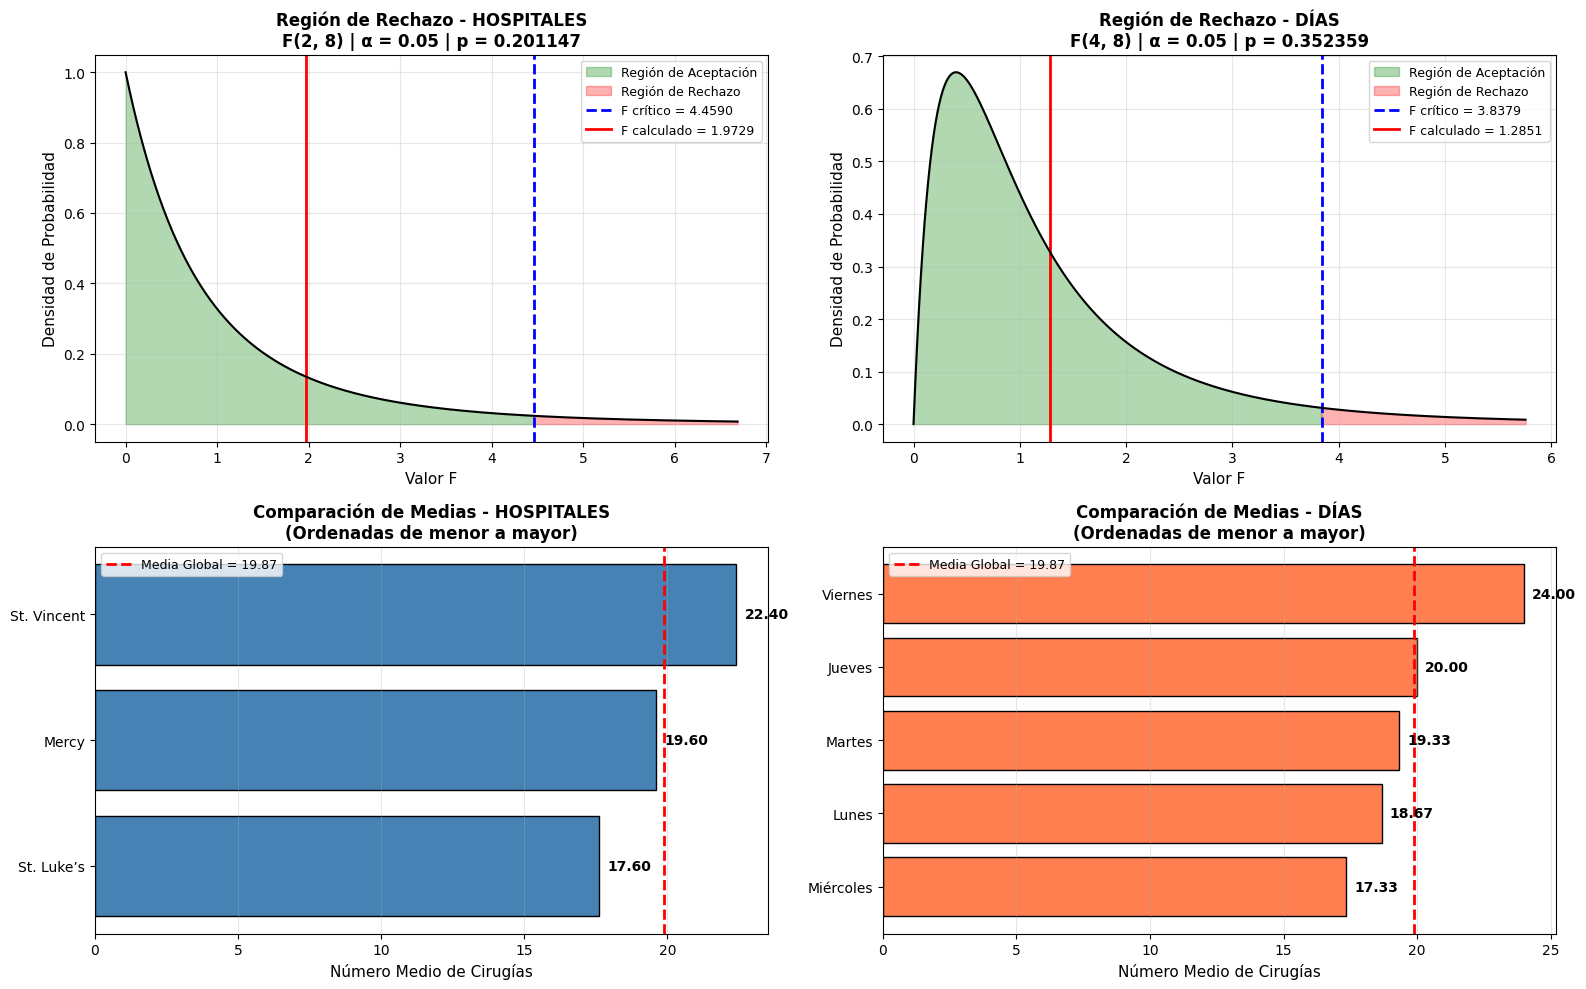

✓ Gráfico guardado como 'tukey_matrices_diferencias_cirugias.png'


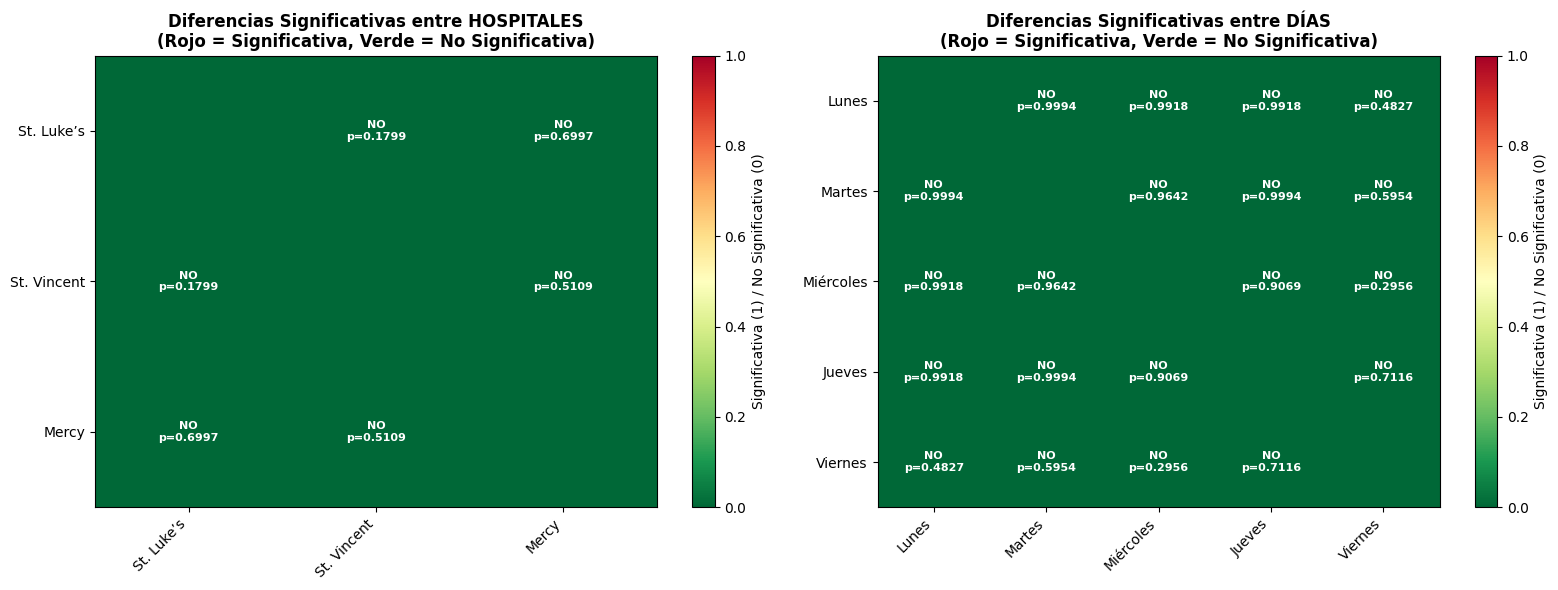


ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Datos del problema
hospitales = ['St. Luke’s', 'St. Vincent', 'Mercy']
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

# Matriz de número de cirugías realizadas
# Las filas representan los días y las columnas los hospitales
datos = np.array([
    [14, 18, 24],  # Lunes
    [20, 24, 14],  # Martes
    [16, 22, 14],  # Miércoles
    [18, 20, 22],  # Jueves
    [20, 28, 24]   # Viernes
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos, index=dias, columns=hospitales)
print("DATOS ORIGINALES:")
print(df)
print("\n" + "="*80 + "\n")

# Preparar datos para ANOVA
n_dias = len(dias)
n_hospitales = len(hospitales)
n_total = n_dias * n_hospitales

# Calcular medias
media_global = np.mean(datos)
# Medias por día (filas)
medias_dias = np.mean(datos, axis=1)
# Medias por hospital (columnas)
medias_hospitales = np.mean(datos, axis=0)

print(f"Media Global: {media_global:.4f}")
print(f"\nMedias por Día:")
for i, dia in enumerate(dias):
    print(f"  {dia}: {medias_dias[i]:.4f}")
print(f"\nMedias por Hospital:")
for i, hospital in enumerate(hospitales):
    print(f"  {hospital}: {medias_hospitales[i]:.4f}")
print("\n" + "="*80 + "\n")

# ============================================================================
# ANOVA DE DOS VÍAS SIN INTERACCIÓN
# ============================================================================

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de días (SCD) - factor fila
SCD = n_hospitales * np.sum((medias_dias - media_global)**2)

# Suma de cuadrados de hospitales (SCH) - factor columna
SCH = n_dias * np.sum((medias_hospitales - media_global)**2)

# Suma de cuadrados del error (SCE)
SCE = SCT - SCD - SCH

# Grados de libertad
gl_dias = n_dias - 1
gl_hospitales = n_hospitales - 1
gl_error = (n_dias - 1) * (n_hospitales - 1)
gl_total = n_total - 1

# Cuadrados medios
CMD = SCD / gl_dias
CMH = SCH / gl_hospitales
CME = SCE / gl_error

# Estadísticos F
F_dias = CMD / CME
F_hospitales = CMH / CME

# Valores p
p_dias = 1 - stats.f.cdf(F_dias, gl_dias, gl_error)
p_hospitales = 1 - stats.f.cdf(F_hospitales, gl_hospitales, gl_error)

# Valores críticos F para α = 0.05
F_crit_dias = stats.f.ppf(0.95, gl_dias, gl_error)
F_crit_hospitales = stats.f.ppf(0.95, gl_hospitales, gl_error)

# Crear tabla ANOVA
print("TABLA ANOVA DE DOS VÍAS")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Días':<20} {SCD:>12.4f} {gl_dias:>6} {CMD:>12.4f} {F_dias:>12.4f} {p_dias:>12.6f} {F_crit_dias:>12.4f}")
print(f"{'Hospitales':<20} {SCH:>12.4f} {gl_hospitales:>6} {CMH:>12.4f} {F_hospitales:>12.4f} {p_hospitales:>12.6f} {F_crit_hospitales:>12.4f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# Interpretación de resultados
alpha = 0.05
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\n1. EFECTO DE DÍAS:")
print(f"   F calculado = {F_dias:.4f}")
print(f"   F crítico   = {F_crit_dias:.4f}")
print(f"   Valor-p     = {p_dias:.6f}")
if p_dias < alpha:
    print(f"   ✓ Hay diferencia significativa entre los días de la semana (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre los días de la semana (p \u2265 {alpha})")

print(f"\n2. EFECTO DE HOSPITALES:")
print(f"   F calculado = {F_hospitales:.4f}")
print(f"   F crítico   = {F_crit_hospitales:.4f}")
print(f"   Valor-p     = {p_hospitales:.6f}")
if p_hospitales < alpha:
    print(f"   ✓ Hay diferencia significativa entre los hospitales (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre los hospitales (p \u2265 {alpha})")

print("\n" + "="*80)
print("\nRESPUESTA A LAS PREGUNTAS:")
print("-" * 80)
print("\n¿Hay diferencia entre los números medios de cirugías realizadas por cada hospital?")
if p_hospitales < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_hospitales:.6f} < 0.05)")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_hospitales:.6f} \u2265 0.05)")

print("\n¿Hay diferencia entre los números medios de cirugías realizadas por día de la semana?")
print("(eliminando el efecto de los hospitales)")
if p_dias < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_dias:.6f} < 0.05)")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_dias:.6f} \u2265 0.05)")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE TUKEY (HSD)")
print("="*80)

# --------------------------------------------------------------------------
# COMPARACIONES PARA HOSPITALES
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES MÚLTIPLES PARA HOSPITALES:")
print("-"*80)

q_hospitales = stats.studentized_range.ppf(0.95, n_hospitales, gl_error)
HSD_hospitales = q_hospitales * np.sqrt(CME / n_dias)

print(f"\nValor crítico q (\u03B1=0.05, k={n_hospitales}, gl_error={gl_error}): {q_hospitales:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_hospitales:.4f}")
print(f"\n{'Hospital i':<15} {'Hospital j':<15} {'Media i':>10} {'Media j':>10} "
      f"{'Diferencia':>12} {'|Dif|':>10} {'q_obs':>8} {'p-valor':>10} {'Significativa':>15}")
print("-"*115)

comparaciones_hospitales = []
for i, j in combinations(range(n_hospitales), 2):
    diff    = medias_hospitales[i] - medias_hospitales[j]
    abs_diff = abs(diff)
    q_obs   = abs_diff / np.sqrt(CME / n_dias)
    p_val   = stats.studentized_range.sf(q_obs, n_hospitales, gl_error)
    es_sig  = "SÍ" if abs_diff > HSD_hospitales else "NO"
    comparaciones_hospitales.append({
        'Hospital_i': hospitales[i], 'Hospital_j': hospitales[j],
        'Media_i': medias_hospitales[i], 'Media_j': medias_hospitales[j],
        'Diferencia': diff, 'Abs_Diferencia': abs_diff,
        'q_obs': q_obs, 'p_valor': p_val, 'Significativa': es_sig
    })
    print(f"{hospitales[i]:<15} {hospitales[j]:<15} {medias_hospitales[i]:>10.4f} {medias_hospitales[j]:>10.4f} "
          f"{diff:>12.4f} {abs_diff:>10.4f} {q_obs:>8.4f} {p_val:>10.6f} {es_sig:>15}")

# --------------------------------------------------------------------------
# COMPARACIONES PARA DÍAS
# --------------------------------------------------------------------------
print("\n" + "-"*80)
print("COMPARACIONES MÚLTIPLES PARA DÍAS:")
print("-"*80)

q_dias = stats.studentized_range.ppf(0.95, n_dias, gl_error)
HSD_dias = q_dias * np.sqrt(CME / n_hospitales)

print(f"\nValor crítico q (\u03B1=0.05, k={n_dias}, gl_error={gl_error}): {q_dias:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_dias:.4f}")
print(f"\n{'Día i':<15} {'Día j':<15} {'Media i':>10} {'Media j':>10} "
      f"{'Diferencia':>12} {'|Dif|':>10} {'q_obs':>8} {'p-valor':>10} {'Significativa':>15}")
print("-"*115)

comparaciones_dias = []
for i, j in combinations(range(n_dias), 2):
    diff    = medias_dias[i] - medias_dias[j]
    abs_diff = abs(diff)
    q_obs   = abs_diff / np.sqrt(CME / n_hospitales)
    p_val   = stats.studentized_range.sf(q_obs, n_dias, gl_error)
    es_sig  = "SÍ" if abs_diff > HSD_dias else "NO"
    comparaciones_dias.append({
        'Día_i': dias[i], 'Día_j': dias[j],
        'Media_i': medias_dias[i], 'Media_j': medias_dias[j],
        'Diferencia': diff, 'Abs_Diferencia': abs_diff,
        'q_obs': q_obs, 'p_valor': p_val, 'Significativa': es_sig
    })
    print(f"{dias[i]:<15} {dias[j]:<15} {medias_dias[i]:>10.4f} {medias_dias[j]:>10.4f} "
          f"{diff:>12.4f} {abs_diff:>10.4f} {q_obs:>8.4f} {p_val:>10.6f} {es_sig:>15}")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 10))

# --- Gráfico 1: Región de rechazo para HOSPITALES ---
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(0, max(F_hospitales, F_crit_hospitales) * 1.5, 1000)
y = stats.f.pdf(x, gl_hospitales, gl_error)

x_accept = x[x <= F_crit_hospitales]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_hospitales, gl_error),
                 alpha=0.3, color='green', label='Región de Aceptación')
x_reject = x[x >= F_crit_hospitales]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_hospitales, gl_error),
                 alpha=0.3, color='red', label='Región de Rechazo')
ax1.axvline(F_crit_hospitales, color='blue', linestyle='--', linewidth=2,
            label=f'F crítico = {F_crit_hospitales:.4f}')
ax1.axvline(F_hospitales, color='red', linestyle='-', linewidth=2,
            label=f'F calculado = {F_hospitales:.4f}')
ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax1.set_title(f'Región de Rechazo - HOSPITALES\nF({gl_hospitales}, {gl_error}) | \u03B1 = 0.05 | p = {p_hospitales:.6f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Región de rechazo para DÍAS ---
ax2 = plt.subplot(2, 2, 2)
x2 = np.linspace(0, max(F_dias, F_crit_dias) * 1.5, 1000)
y2 = stats.f.pdf(x2, gl_dias, gl_error)

x_accept2 = x2[x2 <= F_crit_dias]
ax2.fill_between(x_accept2, 0, stats.f.pdf(x_accept2, gl_dias, gl_error),
                 alpha=0.3, color='green', label='Región de Aceptación')
x_reject2 = x2[x2 >= F_crit_dias]
ax2.fill_between(x_reject2, 0, stats.f.pdf(x_reject2, gl_dias, gl_error),
                 alpha=0.3, color='red', label='Región de Rechazo')
ax2.axvline(F_crit_dias, color='blue', linestyle='--', linewidth=2,
            label=f'F crítico = {F_crit_dias:.4f}')
ax2.axvline(F_dias, color='red', linestyle='-', linewidth=2,
            label=f'F calculado = {F_dias:.4f}')
ax2.plot(x2, y2, 'k-', linewidth=1.5)
ax2.set_xlabel('Valor F', fontsize=11)
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax2.set_title(f'Región de Rechazo - DÍAS\nF({gl_dias}, {gl_error}) | \u03B1 = 0.05 | p = {p_dias:.6f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Medias por HOSPITALES ---
ax3 = plt.subplot(2, 2, 3)
hospitales_ordenados = sorted(range(n_hospitales), key=lambda i: medias_hospitales[i])
medias_ord_hospitales = [medias_hospitales[i] for i in hospitales_ordenados]
nombres_ord_hospitales = [hospitales[i] for i in hospitales_ordenados]

bars3 = ax3.barh(nombres_ord_hospitales, medias_ord_hospitales, color='steelblue', edgecolor='black')
ax3.axvline(media_global, color='red', linestyle='--', linewidth=2,
            label=f'Media Global = {media_global:.2f}')
ax3.set_xlabel('Número Medio de Cirugías', fontsize=11)
ax3.set_title('Comparación de Medias - HOSPITALES\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars3, medias_ord_hospitales):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

# --- Gráfico 4: Medias por DÍAS ---
ax4 = plt.subplot(2, 2, 4)
dias_ordenados = sorted(range(n_dias), key=lambda i: medias_dias[i])
medias_ord_dias = [medias_dias[i] for i in dias_ordenados]
nombres_ord_dias = [dias[i] for i in dias_ordenados]

bars4 = ax4.barh(nombres_ord_dias, medias_ord_dias, color='coral', edgecolor='black')
ax4.axvline(media_global, color='red', linestyle='--', linewidth=2,
            label=f'Media Global = {media_global:.2f}')
ax4.set_xlabel('Número Medio de Cirugías', fontsize=11)
ax4.set_title('Comparación de Medias - DÍAS\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars4, medias_ord_dias):
    ax4.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('anova_dos_vias_analisis_cirugias.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'anova_dos_vias_analisis_cirugias.png'")
plt.show()

# ============================================================================
# MATRICES DE DIFERENCIAS SIGNIFICATIVAS (Tukey)
# ============================================================================

fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# --- Matriz HOSPITALES ---
diff_matrix_hospitales = np.zeros((n_hospitales, n_hospitales))
for i in range(n_hospitales):
    for j in range(n_hospitales):
        if i != j:
            diff = abs(medias_hospitales[i] - medias_hospitales[j])
            diff_matrix_hospitales[i, j] = 1 if diff > HSD_hospitales else 0

im1 = ax5.imshow(diff_matrix_hospitales, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(n_hospitales))
ax5.set_yticks(range(n_hospitales))
ax5.set_xticklabels(hospitales, rotation=45, ha='right')
ax5.set_yticklabels(hospitales)
ax5.set_title('Diferencias Significativas entre HOSPITALES\n(Rojo = Significativa, Verde = No Significativa)',
              fontsize=12, fontweight='bold')
for i in range(n_hospitales):
    for j in range(n_hospitales):
        if i != j:
            # Mostrar valor p de Tukey dentro de la celda
            q_ij  = abs(medias_hospitales[i] - medias_hospitales[j]) / np.sqrt(CME / n_dias)
            p_ij  = stats.studentized_range.sf(q_ij, n_hospitales, gl_error)
            label = f"{'SÍ' if diff_matrix_hospitales[i,j]==1 else 'NO'}\np={p_ij:.4f}"
            ax5.text(j, i, label, ha='center', va='center',
                     color='white', fontweight='bold', fontsize=8)
plt.colorbar(im1, ax=ax5, label='Significativa (1) / No Significativa (0)')

# --- Matriz DÍAS ---
diff_matrix_dias = np.zeros((n_dias, n_dias))
for i in range(n_dias):
    for j in range(n_dias):
        if i != j:
            diff = abs(medias_dias[i] - medias_dias[j])
            diff_matrix_dias[i, j] = 1 if diff > HSD_dias else 0

im2 = ax6.imshow(diff_matrix_dias, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(n_dias))
ax6.set_yticks(range(n_dias))
ax6.set_xticklabels(dias, rotation=45, ha='right')
ax6.set_yticklabels(dias)
ax6.set_title('Diferencias Significativas entre DÍAS\n(Rojo = Significativa, Verde = No Significativa)',
              fontsize=12, fontweight='bold')
for i in range(n_dias):
    for j in range(n_dias):
        if i != j:
            # Mostrar valor p de Tukey dentro de la celda
            q_ij  = abs(medias_dias[i] - medias_dias[j]) / np.sqrt(CME / n_hospitales)
            p_ij  = stats.studentized_range.sf(q_ij, n_dias, gl_error)
            label = f"{'SÍ' if diff_matrix_dias[i,j]==1 else 'NO'}\np={p_ij:.4f}"
            ax6.text(j, i, label, ha='center', va='center',
                     color='white', fontweight='bold', fontsize=8)
plt.colorbar(im2, ax=ax6, label='Significativa (1) / No Significativa (0)')

plt.tight_layout()
plt.savefig('tukey_matrices_diferencias_cirugias.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado como 'tukey_matrices_diferencias_cirugias.png'")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)